In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
path = Path('input')
geography = pd.read_csv(path / 'geography.csv')
customers = pd.read_csv(path / 'customers.csv')
orders = pd.read_csv(path / 'orders.csv')
order_items = pd.read_csv(path / 'order_items.csv')
promotions = pd.read_csv(path / 'promotions.csv')

print("Data loaded successfully")
print(f"Geography: {geography.shape}, Customers: {customers.shape}")
print(f"Orders: {orders.shape}, Order Items: {order_items.shape}")
print(f"Promotions: {promotions.shape}")
print("\n" + "="*80)

Data loaded successfully
Geography: (39948, 4), Customers: (121930, 7)
Orders: (646945, 8), Order Items: (714669, 7)
Promotions: (50, 10)



C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_18132\266126918.py:16: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(path / 'order_items.csv')


In [10]:
# STEP 1: Revenue & Customer Distribution by Region
print("\n📊 STEP 1: REVENUE & CUSTOMER DISTRIBUTION BY REGION")
print("="*80)

# Merge orders with order_items to get revenue
orders_with_items = orders.merge(order_items, on='order_id', how='left')

# Merge with geography to get region (orders already has zip)
orders_region = orders_with_items.merge(geography[['zip', 'region', 'city']], on='zip', how='left')

# Calculate metrics by region
region_metrics = orders_region.groupby('region', observed=True).agg({
    'order_id': 'nunique',  # Number of orders
    'customer_id': 'nunique',  # Number of unique customers
    'unit_price': ['sum', 'mean', 'median'],  # Revenue metrics
}).round(2)

region_metrics.columns = ['Order_Count', 'Customer_Count', 'Total_Revenue', 'Avg_Item_Price', 'Median_Item_Price']

# Add repeat purchase metric
repeat_customers_by_region = orders_region.groupby('region', observed=True)['customer_id'].apply(
    lambda x: x.value_counts().sum() / len(x.unique())
).round(2)
region_metrics['Avg_Orders_Per_Customer'] = repeat_customers_by_region

print("\n📈 Region Summary Table:")
print(region_metrics)

# Calculate AOV (Average Order Value) by region
aov_by_region = orders_region.groupby(['region', 'order_id'], observed=True)['unit_price'].sum().groupby('region').mean().round(2)
print("\n💰 Average Order Value (AOV) by Region:")
print(aov_by_region)

# Market share
total_revenue = orders_region['unit_price'].sum()
revenue_by_region = orders_region.groupby('region', observed=True)['unit_price'].sum()
market_share = (revenue_by_region / total_revenue * 100).round(2)

print("\n🎯 Revenue Market Share by Region:")
print(market_share)
print(f"\nTotal Revenue Across All Regions: ${total_revenue:,.2f}")


📊 STEP 1: REVENUE & CUSTOMER DISTRIBUTION BY REGION

📈 Region Summary Table:
         Order_Count  Customer_Count  Total_Revenue  Avg_Item_Price  \
region                                                                
Central       184691           30784   1.096904e+09         5447.96   
East          294612           44721   1.700357e+09         5292.23   
West          167642           14741   8.580491e+08         4468.21   

         Median_Item_Price  Avg_Orders_Per_Customer  
region                                               
Central            4488.80                     6.54  
East               4446.55                     7.18  
West               3816.84                    13.03  

💰 Average Order Value (AOV) by Region:
region
Central    5939.13
East       5771.51
West       5118.34
Name: unit_price, dtype: float64

🎯 Revenue Market Share by Region:
region
Central    30.01
East       46.52
West       23.47
Name: unit_price, dtype: float64

Total Revenue Across All Regions

In [11]:
# STEP 2: Campaign Penetration by Region
print("\n\n🎯 STEP 2: CAMPAIGN PENETRATION BY REGION")
print("="*80)

# Check if 'promo_id' exists in order_items
if 'promo_id' in order_items.columns:
    # Merge orders with order_items to get promo info
    orders_promo = orders.merge(order_items, on='order_id', how='left')
    
    # Merge with promotions
    orders_promo = orders_promo.merge(promotions[['promo_id', 'promo_name', 'promo_type']], 
                                      on='promo_id', how='left')
    
    # Merge with geography to get region
    orders_promo_geo = orders_promo.merge(geography[['zip', 'region']], on='zip', how='left')
    
    # Campaign penetration: % of orders with promo by region
    campaign_metrics = orders_promo_geo.groupby('region', observed=True).agg({
        'order_id': 'nunique',  # Total orders
        'promo_id': lambda x: x.notna().sum(),  # Orders with promo
    }).round(0)
    
    campaign_metrics.columns = ['Total_Orders', 'Orders_With_Promo']
    campaign_metrics['Promo_Penetration_%'] = (
        campaign_metrics['Orders_With_Promo'] / campaign_metrics['Total_Orders'] * 100
    ).round(2)
    
    # Promo type distribution by region
    promo_type_region = pd.crosstab(
        orders_promo_geo['region'], 
        orders_promo_geo['promo_type'], 
        margins=True
    )
    
    print("\n🎁 Campaign Penetration by Region:")
    print(campaign_metrics)
    
    print("\n📋 Promo Type Distribution by Region:")
    print(promo_type_region)
    
    # Deep dive: avg discount by region
    if 'discount_amount' in order_items.columns:
        avg_discount = orders_promo_geo.groupby('region', observed=True)['discount_amount'].mean().round(2)
        print("\n💵 Average Discount Value by Region:")
        print(avg_discount)
else:
    print("⚠️  No promo_id column found in order_items. Skipping campaign penetration analysis.")
    campaign_metrics = None

print("\n✅ Analysis complete!")



🎯 STEP 2: CAMPAIGN PENETRATION BY REGION

🎁 Campaign Penetration by Region:
         Total_Orders  Orders_With_Promo  Promo_Penetration_%
region                                                       
Central        184691              77919                42.19
East           294612             124709                42.33
West           167642              73688                43.96

📋 Promo Type Distribution by Region:
promo_type  fixed  percentage     All
region                               
Central      6569       71350   77919
East        10083      114626  124709
West         4298       69390   73688
All         20950      255366  276316

💵 Average Discount Value by Region:
region
Central    1104.67
East       1078.09
West        941.54
Name: discount_amount, dtype: float64

✅ Analysis complete!




📊 STEP 3: VISUALIZATIONS


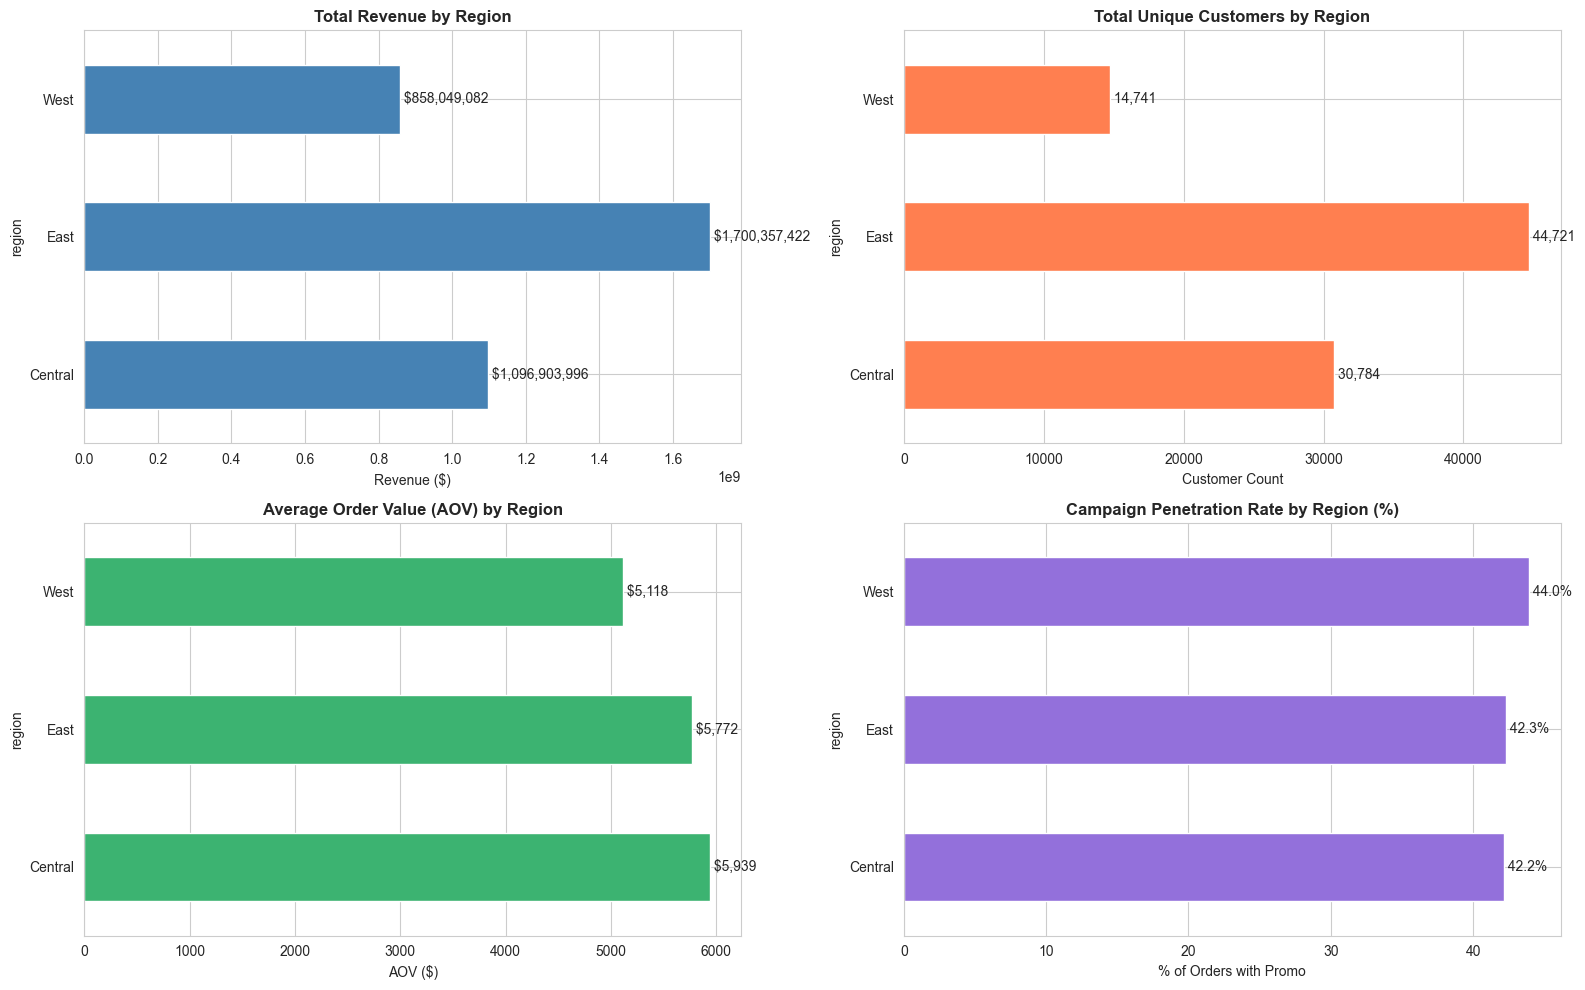

✅ Visualization saved as 'geography_analysis.png'


In [12]:
# STEP 3: Visualizations
print("\n\n📊 STEP 3: VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Revenue by Region
ax1 = axes[0, 0]
revenue_by_region.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Total Revenue by Region', fontsize=12, fontweight='bold')
ax1.set_xlabel('Revenue ($)')
for i, v in enumerate(revenue_by_region.values):
    ax1.text(v, i, f' ${v:,.0f}', va='center')

# Plot 2: Customer Count by Region
ax2 = axes[0, 1]
customer_counts = orders_region.groupby('region', observed=True)['customer_id'].nunique()
customer_counts.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Total Unique Customers by Region', fontsize=12, fontweight='bold')
ax2.set_xlabel('Customer Count')
for i, v in enumerate(customer_counts.values):
    ax2.text(v, i, f' {v:,.0f}', va='center')

# Plot 3: AOV (Average Order Value) by Region
ax3 = axes[1, 0]
aov_by_region.plot(kind='barh', ax=ax3, color='mediumseagreen')
ax3.set_title('Average Order Value (AOV) by Region', fontsize=12, fontweight='bold')
ax3.set_xlabel('AOV ($)')
for i, v in enumerate(aov_by_region.values):
    ax3.text(v, i, f' ${v:,.0f}', va='center')

# Plot 4: Campaign Penetration by Region (if available)
if campaign_metrics is not None:
    ax4 = axes[1, 1]
    campaign_metrics['Promo_Penetration_%'].plot(kind='barh', ax=ax4, color='mediumpurple')
    ax4.set_title('Campaign Penetration Rate by Region (%)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('% of Orders with Promo')
    for i, v in enumerate(campaign_metrics['Promo_Penetration_%'].values):
        ax4.text(v, i, f' {v:.1f}%', va='center')
else:
    ax4 = axes[1, 1]
    ax4.text(0.5, 0.5, 'No Promotion Data Available', 
             ha='center', va='center', fontsize=12)
    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)
    ax4.axis('off')

plt.tight_layout()
plt.savefig('geography_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as 'geography_analysis.png'")

In [13]:
# STEP 4: Key Insights & Recommendations
print("\n\n🎯 KEY INSIGHTS & STRATEGIC RECOMMENDATIONS")
print("="*80)

# Identify over-indexed regions (high campaign penetration)
if campaign_metrics is not None:
    promo_penet = campaign_metrics['Promo_Penetration_%']
    high_campaign = promo_penet[promo_penet > promo_penet.mean()]
    low_campaign = promo_penet[promo_penet < promo_penet.mean()]
    
    print("\n1️⃣  CAMPAIGN FOCUS (Over-Indexed Regions):")
    if len(high_campaign) > 0:
        for region, pct in high_campaign.items():
            print(f"   ✓ {region}: {pct:.1f}% of orders have promos (ABOVE average)")
    else:
        print("   No over-indexed regions found")
    
    print("\n2️⃣  UNDER-PENETRATED REGIONS (Opportunity for Growth):")
    if len(low_campaign) > 0:
        for region, pct in low_campaign.items():
            print(f"   ⚠️  {region}: {pct:.1f}% of orders have promos (BELOW average)")
    else:
        print("   All regions equally penetrated")

# Identify high-value regions by AOV vs market share
print("\n3️⃣  HIGH-VALUE REGIONS (by AOV):")
top_aov = aov_by_region.nlargest(3)
for region, aov in top_aov.items():
    share = market_share[region]
    print(f"   💰 {region}: AOV = ${aov:,.0f} | Market Share = {share:.1f}%")

print("\n4️⃣  STRATEGIC SUMMARY:")
print("   • Regions with HIGH promo penetration = Already mature/contested markets")
print("   • Regions with LOW promo penetration = Growth opportunity (less defended)")
print("   • High AOV regions = Premium customer base or premium product mix")
print("   • Market share ≠ saturation: Check ratio of campaign intensity vs revenue")

print("\n5️⃣  NEXT STEPS:")
print("   → Test increasing promos in low-penetration regions")
print("   → Analyze customer acquisition cost (CAC) by region & channel")
print("   → Check if high-campaign regions have fatigue (declining repeat rate)")
print("="*80)



🎯 KEY INSIGHTS & STRATEGIC RECOMMENDATIONS

1️⃣  CAMPAIGN FOCUS (Over-Indexed Regions):
   ✓ West: 44.0% of orders have promos (ABOVE average)

2️⃣  UNDER-PENETRATED REGIONS (Opportunity for Growth):
   ⚠️  Central: 42.2% of orders have promos (BELOW average)
   ⚠️  East: 42.3% of orders have promos (BELOW average)

3️⃣  HIGH-VALUE REGIONS (by AOV):
   💰 Central: AOV = $5,939 | Market Share = 30.0%
   💰 East: AOV = $5,772 | Market Share = 46.5%
   💰 West: AOV = $5,118 | Market Share = 23.5%

4️⃣  STRATEGIC SUMMARY:
   • Regions with HIGH promo penetration = Already mature/contested markets
   • Regions with LOW promo penetration = Growth opportunity (less defended)
   • High AOV regions = Premium customer base or premium product mix
   • Market share ≠ saturation: Check ratio of campaign intensity vs revenue

5️⃣  NEXT STEPS:
   → Test increasing promos in low-penetration regions
   → Analyze customer acquisition cost (CAC) by region & channel
   → Check if high-campaign regions have

Key Insights:
East region: Highest revenue & customer base (mature market)

West region: Highest promo penetration (44%) - chiến dịch tập trung vào đây

Central region: Highest AOV nhưng promo penetration thấp - có tiềm năng tăng campaign